In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import os 
import sys 
import tempfile 
import subprocess 

In [3]:
ds

<xarray.Dataset>
Dimensions:  (face: 12, height: 64, width: 64, time: 556)
Coordinates:
  * face     (face) int32 0 1 2 3 4 5 6 7 8 9 10 11
  * height   (height) int32 0 1 2 3 4 5 6 7 8 9 ... 55 56 57 58 59 60 61 62 63
  * width    (width) int32 0 1 2 3 4 5 6 7 8 9 ... 54 55 56 57 58 59 60 61 62 63
  * time     (time) datetime64[ns] 1978-10-16 1978-11-16 ... 2025-01-16
Data variables:
    pr       (time, face, height, width) float32 ...
Attributes:
    Conventions:     CF-1.8
    source_id:       DLESyM
    institution_id:  University of Washington
    time_units:      days since 1850-01-01 00:00:00
    time_calendar:   gregorian

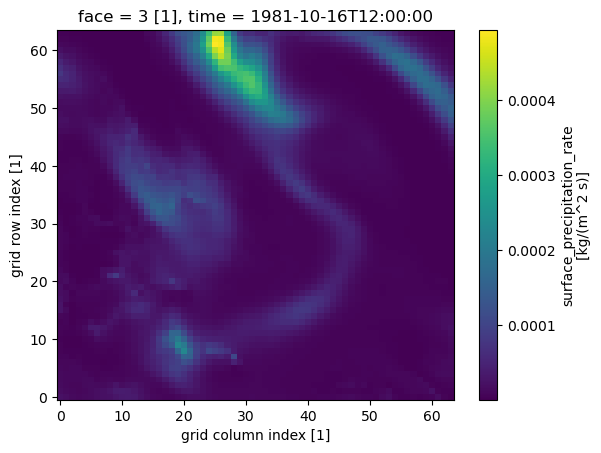

In [14]:
ds = xr.open_dataset('/home/disk/mercury3/nacc/aimip_subission_1978/university_of_washington/DLESyM/aimip-p2k/r5i1p1f1/day/pr/gn/v20260406/pr_day_DLESyM_aimip-p2k_r5i1p1f1_gn_19781007-19841231.nc')
# select data 
da = ds.pr.sel(time='1981-10-16', face=3)
da.plot()
# plot first 

In [16]:
da

<xarray.DataArray 'tp6' (height: 64, width: 64)>
[4096 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 1978-10-07T06:00:00
    step     timedelta64[ns] 00:00:00
    face     int64 3
  * height   (height) int64 0 1 2 3 4 5 6 7 8 9 ... 55 56 57 58 59 60 61 62 63
  * width    (width) int64 0 1 2 3 4 5 6 7 8 9 ... 54 55 56 57 58 59 60 61 62 63

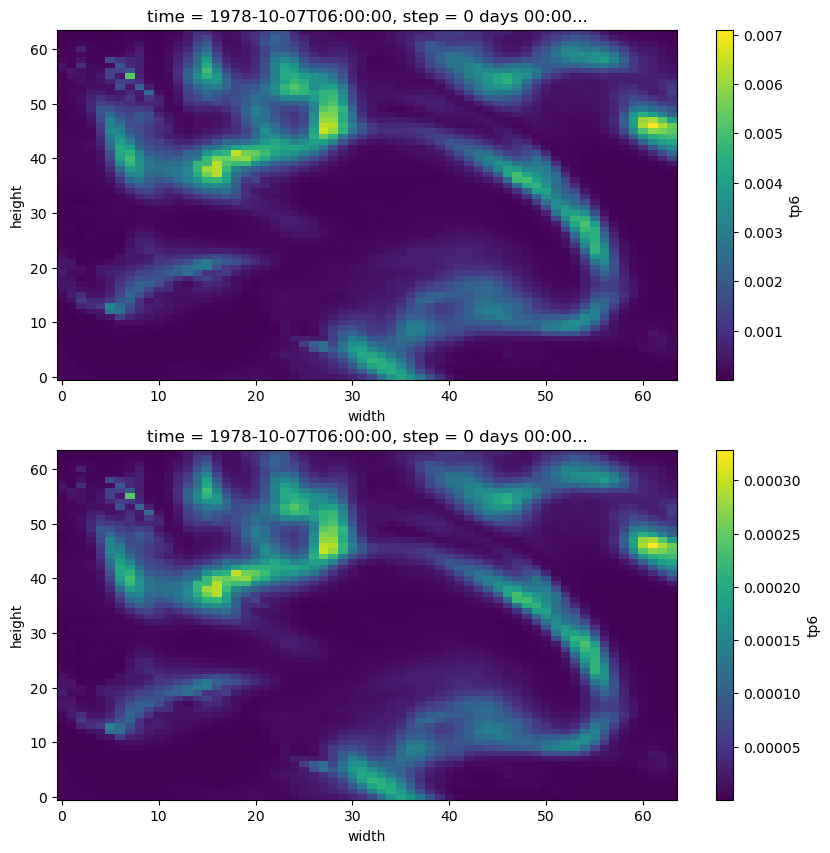

In [17]:
# plot daa=
fig, ax = plt.subplots(figsize=(10, 10),nrows=2)

rho = 1000.0  # kg/m^3
dt = 6 * 3600  # s
rate = (rho * da) / dt  # kg/(m^2 s); attributes/units you should set yourself

da.plot(ax=ax[0])
rate.plot(ax=ax[1])
plt.show()


In [1]:
import os
import sys
import tempfile
import subprocess
import shutil
import s3fs

In [3]:
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://s3.eu-dkrz-1.dkrz.cloud"},
    key=os.environ.get("DKRZ_S3_KEY", "PvUwMS8lvawlRecf5Bnp"),
    secret=os.environ.get("DKRZ_S3_SECRET", "NXrq2PGaBy2pig2Lhgmr85Bdk3tZtkYTsmsunrDh"),
)
bucket = "ai-mip"
remote_prefix = f"{bucket}/DLESyM/"

In [4]:
paths = fs.find(f"{bucket}/DLESyM/", maxdepth=20)  # tune depth
counter = 0
for p in paths[:50]:
    print(p)
    counter += 1
print(f'{counter} files found')


EndpointConnectionError: Could not connect to the endpoint URL: "https://s3.eu-dkrz-1.dkrz.cloud/ai-mip?list-type=2&prefix=DLESyM%2F&delimiter=%2F&encoding-type=url"

In [40]:
key = (
    "ai-mip/DLESyM/DLESyM/aimip-p2k/r1i1p1f1/Amon/ta/gn/v20250825/"
    "ta_Amon_DLESyM_aimip-p2k_r1i1p1f1_gn_19781016-20241216.nc"
)

assert fs.exists(key), f"not found: {key}"
fs.rm(key)

[]

In [16]:
import xarray as xr

In [ ]:

url = "s3://ai-mip/DLESyM/path/to/file.nc"
ds = xr.open_dataset(url, storage_options={
    "client_kwargs": {"endpoint_url": "https://s3.eu-dkrz-1.dkrz.cloud"},
    "key": "PvUwMS8lvawlRecf5Bnp",
    "secret": "NXrq2PGaBy2pig2Lhgmr85Bdk3tZtkYTsmsunrDh",
})


TypeError: NetCDF4BackendEntrypoint.open_dataset() got an unexpected keyword argument 'storage_options'

In [1]:
import xarray as xr

ds = xr.open_dataset('/home/disk/mercury3/nacc/aimip_subission_1978/university_of_washington/DLESyM/aimip-p2k/r1i1p1f1/Amon/pr/gn/v20260406/pr_Amon_DLESyM_aimip-p2k_r1i1p1f1_gn_19781016-20241216.nc')

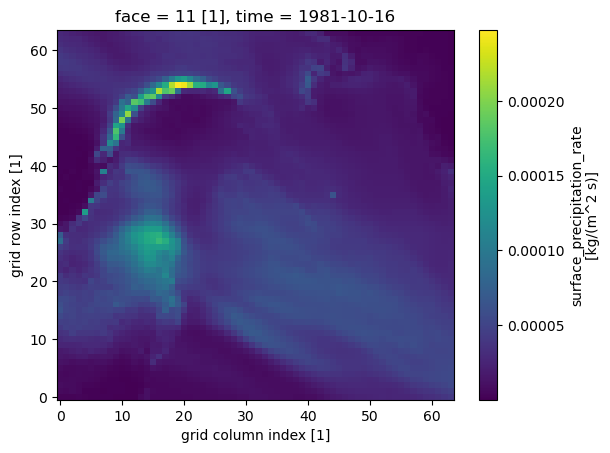

In [4]:
da = ds.pr.sel(time='1981-10-16', face=11)
da.plot()